# The Effect of Weather on S&P 500 Market Performance
Yelizaveta Nazarova 

ECO590

Spring 2026 

## This notebook contains work with Weather API and S&P 500 CSV File 

## Motivation 
Modern research on financial markets often discusses the influence of external factors on market behavior. I became interested in whether weather conditions can be considered one of these factors, specifically whether weather affects the S&P 500 index and how this knowledge could improve our understanding of market behavior. Using weather data and S&P 500 market data, I conduct a regression analysis to determine whether a relationship exists between weather conditions and the performance of the index.

## Research Question
Do weather conditions influence investor behavior in financial markets?

# Collecting Weather Data Using API and Merging it with S&P 500 Dataset

### Packages needed

In [49]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Using the Open-Meteo API documentation, I learned that historical weather data can be accessed through a specific archive API URL. The documentation shows that the user needs to provide several parameters in the request, such as latitude, longitude, start date, end date, and the daily weather variables needed for the analysis. In my project, I used the coordinates for New York City, where latitude is 40.7128 and longitude is -74.0060. I also selected the time period for the dataset and requested daily variables including mean temperature, relative humidity, cloud cover, and maximum wind speed.


### Open Meteo API (Weather Data)

To have access to historical weather data, I used a specific archive API URL. The documentation showed that I needed to provide parameters such as latitude, longitude, start date, and end date in order to get results for my region. In my project, I used the coordinates for New York City, where the latitude is 40.7128 and the longitude is -74.0060. I also requested the variables needed for my dataset directly in the URL. After that, I retrieved daily weather data for further analysis.

In [19]:
url = "https://archive-api.open-meteo.com/v1/archive?latitude=40.7128&longitude=-74.0060&start_date=2025-01-01&end_date=2026-04-09&daily=temperature_2m_mean,relative_humidity_2m_mean,cloudcover_mean,windspeed_10m_max&timezone=America/New_York"
# API request link with location, dates, and variables
response = requests.get(url) # Sends request to the API
weather_data = response.json() # Converts API response into JSON format

print(weather_data.keys()) # Displays names of the variables in the dataset

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [20]:
#Creating dataframe with daily variables
daily = weather_data["daily"] # Extracts daily weather data

weather_df = pd.DataFrame(daily) # Converts data into a DataFrame (using pandas)

weather_df.head() # Shows first 5 rows of the dataset

,time,temperature_2m_mean,relative_humidity_2m_mean,cloudcover_mean,windspeed_10m_max
0,2025-01-01,7.4,81,45,23.2
1,2025-01-02,2.6,56,33,25.1
2,2025-01-03,0.4,59,36,17.1
3,2025-01-04,-1.4,51,56,26.1
4,2025-01-05,-2.2,52,51,19.9


In [21]:
#renaming columns 
weather_df.columns = [
    "date",
    "temperature",
    "humidity",
    "cloud_cover",
    "wind_speed"
]

weather_df.head() # Displays updated dataset

,date,temperature,humidity,cloud_cover,wind_speed
0,2025-01-01,7.4,81,45,23.2
1,2025-01-02,2.6,56,33,25.1
2,2025-01-03,0.4,59,36,17.1
3,2025-01-04,-1.4,51,56,26.1
4,2025-01-05,-2.2,52,51,19.9


In [22]:
weather_df.to_csv("weather_data.csv", index=False) #Creating CSV file with dataset

### S&P 500 Dataset (Downloaded from Bloomberg Lab)

In [23]:
spy_df = pd.read_csv('/Users/liza/Desktop/ECO590/dataspyeco590.csv')
spy_df = spy_df.dropna(subset=["Date"]) # Removes rows with missing dates
spy_df["Date"] = pd.to_datetime(spy_df["Date"], format="%d/%m/%y") # Converts date column into datetime format


spy_df.head() # Displays first 5 rows of the dataset

,Date,PX_LAST,Change,% Change,PX_OPEN,Change.1,% Change.1,PX_HIGH,Change.2,% Change.2,PX_LOW,Change.3,% Change.3
0,2026-04-09,679.17,3.16,0.467449,674.84,-1.17,-0.173074,681.16,5.15,0.761823,673.77,-2.24,-0.331356
1,2026-04-08,676.01,16.79,2.546949,676.39,17.17,2.604593,677.08,17.86,2.709262,671.46,12.24,1.856740
2,2026-04-07,659.22,0.29,0.044011,656.65,-2.28,-0.346016,659.61,0.68,0.103198,651.06,-7.87,-1.194361
3,2026-04-06,658.93,3.10,0.472683,655.86,0.03,0.004574,659.72,3.89,0.593142,655.52,-0.31,-0.047268
4,2026-04-02,655.83,0.59,0.090043,646.42,-8.82,-1.346072,658.20,2.96,0.451743,645.11,-10.13,-1.545998


In [24]:
#renaming columns 
spy_df.columns = [
    "date",
    "close",
    "change_close",
    "daily_return",
    "open",
    "change_open",
    "return_open",
    "high",
    "change_high",
    "return_high",
    "low",
    "change_low",
    "return_low"
]
spy_df.head() # Displays updated dataset

,date,close,change_close,daily_return,open,change_open,return_open,high,change_high,return_high,low,change_low,return_low
0,2026-04-09,679.17,3.16,0.467449,674.84,-1.17,-0.173074,681.16,5.15,0.761823,673.77,-2.24,-0.331356
1,2026-04-08,676.01,16.79,2.546949,676.39,17.17,2.604593,677.08,17.86,2.709262,671.46,12.24,1.856740
2,2026-04-07,659.22,0.29,0.044011,656.65,-2.28,-0.346016,659.61,0.68,0.103198,651.06,-7.87,-1.194361
3,2026-04-06,658.93,3.10,0.472683,655.86,0.03,0.004574,659.72,3.89,0.593142,655.52,-0.31,-0.047268
4,2026-04-02,655.83,0.59,0.090043,646.42,-8.82,-1.346072,658.20,2.96,0.451743,645.11,-10.13,-1.545998


In [32]:
#Merging 2 datasets 
spy_df['date'] = pd.to_datetime(spy_df['date']) # Converts S&P 500 date column to datetime format
weather_df['date'] = pd.to_datetime(weather_df['date']) # Converts weather date column to datetime format

merged_df = pd.merge(spy_df, weather_df, on="date", how="inner") # Merges datasets using matching dates

merged_df.head() # Displays first 5 rows of merged dataset

,date,close,change_close,daily_return,open,change_open,return_open,high,change_high,return_high,low,change_low,return_low,temperature,humidity,cloud_cover,wind_speed
0,2026-04-09,679.17,3.16,0.467449,674.84,-1.17,-0.173074,681.16,5.15,0.761823,673.77,-2.24,-0.331356,4.9,71,23,13.9
1,2026-04-08,676.01,16.79,2.546949,676.39,17.17,2.604593,677.08,17.86,2.709262,671.46,12.24,1.856740,3.1,52,0,14.3
2,2026-04-07,659.22,0.29,0.044011,656.65,-2.28,-0.346016,659.61,0.68,0.103198,651.06,-7.87,-1.194361,7.6,53,38,23.3
3,2026-04-06,658.93,3.10,0.472683,655.86,0.03,0.004574,659.72,3.89,0.593142,655.52,-0.31,-0.047268,8.8,50,32,21.1
4,2026-04-02,655.83,0.59,0.090043,646.42,-8.82,-1.346072,658.20,2.96,0.451743,645.11,-10.13,-1.545998,8.1,79,100,21.7


In [34]:
# Sanity check for merged dataset

print("S&P 500 rows:", len(spy_df)) # Prints number of rows in S&P 500 dataset
print("Weather rows:", len(weather_df)) # Prints number of rows in weather dataset
print("Merged rows:", len(merged_df)) # Prints number of rows after merging

print("Missing values:") 
print(merged_df.isnull().sum()) # Counts missing values in each column

print("Date range:")
print(merged_df["date"].min()) # Shows earliest date
print(merged_df["date"].max()) # Shows latest date

print("Duplicated dates:")
print(merged_df["date"].duplicated().sum()) # Counts duplicated dates

merged_df[["date", "close", "daily_return", "temperature", "humidity", "cloud_cover", "wind_speed"]].head() # Displays first 5 rows of merged dataset

S&P 500 rows: 251
Weather rows: 464
Merged rows: 251
Missing values:
date            0
close           0
change_close    1
daily_return    1
open            0
change_open     1
return_open     1
high            0
change_high     1
return_high     1
low             0
change_low      1
return_low      1
temperature     0
humidity        0
cloud_cover     0
wind_speed      0
dtype: int64
Date range:
2025-04-09 00:00:00
2026-04-09 00:00:00
Duplicated dates:
0


,date,close,daily_return,temperature,humidity,cloud_cover,wind_speed
0,2026-04-09,679.17,0.467449,4.9,71,23,13.9
1,2026-04-08,676.01,2.546949,3.1,52,0,14.3
2,2026-04-07,659.22,0.044011,7.6,53,38,23.3
3,2026-04-06,658.93,0.472683,8.8,50,32,21.1
4,2026-04-02,655.83,0.090043,8.1,79,100,21.7


In [35]:
merged_df = merged_df[["date", "close", "daily_return","temperature","humidity","cloud_cover","wind_speed"]]
merged_df.head()

,date,close,daily_return,temperature,humidity,cloud_cover,wind_speed
0,2026-04-09,679.17,0.467449,4.9,71,23,13.9
1,2026-04-08,676.01,2.546949,3.1,52,0,14.3
2,2026-04-07,659.22,0.044011,7.6,53,38,23.3
3,2026-04-06,658.93,0.472683,8.8,50,32,21.1
4,2026-04-02,655.83,0.090043,8.1,79,100,21.7


#### Creating New Calculated Varibales

In [42]:
merged_df["good_weather"] = (
    (merged_df["temperature"].between(5, 22)) &
    (merged_df["cloud_cover"] < 60) &
    (merged_df["wind_speed"] < 25)
).astype(int)
# Creates a dummy variable for good weather days
# 1 = good weather, 0 = otherwise 
merged_df["bad_weather"] = (
    (merged_df["temperature"] < 3) |
    (merged_df["temperature"] > 30) |
    (merged_df["cloud_cover"] >= 70) |
    (merged_df["wind_speed"] >= 40)
).astype(int)
# Creates a dummy variable for bad weather days
# 1 = good weather, 0 = otherwise

merged_df.head()# Displays first 5 rows of merged dataset

,date,close,daily_return,temperature,humidity,cloud_cover,wind_speed,good_weather,bad_weather
0,2026-04-09,679.17,0.467449,4.9,71,23,13.9,0,0
1,2026-04-08,676.01,2.546949,3.1,52,0,14.3,0,0
2,2026-04-07,659.22,0.044011,7.6,53,38,23.3,1,0
3,2026-04-06,658.93,0.472683,8.8,50,32,21.1,1,0
4,2026-04-02,655.83,0.090043,8.1,79,100,21.7,0,1


In [43]:
merged_df["good_weather"].value_counts() # To look how many days match my criteria

good_weather
0    203
1     48
Name: count, dtype: int64

In [44]:
merged_df["bad_weather"].value_counts() # To look how many days match my criteria

bad_weather
1    146
0    105
Name: count, dtype: int64

In [45]:
merged_df

,date,close,daily_return,temperature,humidity,cloud_cover,wind_speed,good_weather,bad_weather
0,2026-04-09,679.17,0.467449,4.9,71,23,13.9,0,0
1,2026-04-08,676.01,2.546949,3.1,52,0,14.3,0,0
2,2026-04-07,659.22,0.044011,7.6,53,38,23.3,1,0
3,2026-04-06,658.93,0.472683,8.8,50,32,21.1,1,0
4,2026-04-02,655.83,0.090043,8.1,79,100,21.7,0,1
...,...,...,...,...,...,...,...,...,...
246,2025-04-15,537.61,-0.280086,13.4,66,65,26.7,0,0
247,2025-04-14,539.12,0.970146,10.6,65,77,11.3,0,1
248,2025-04-11,533.94,1.784285,5.8,85,100,17.9,0,1
249,2025-04-10,524.58,-4.381904,5.2,68,77,17.2,0,1


In [46]:
merged_df.to_csv("final_dataset.csv", index=False)

## Assignment Summary
The weather data in this project was collected using the Open-Meteo API, while the S&P 500 dataset was downloaded from Bloomberg Lab. The weather dataset includes daily information for New York City from January 2025 to April 2026.

In total, I used five weather variables: temperature, humidity, cloud cover, wind speed, and date. From the S&P 500 dataset, I used market variables such as closing price, opening price, daily returns, highs, and lows.

The datasets were cleaned and merged by date using pandas in Python. Dates were converted into datetime format to ensure accurate matching between the financial and weather data. A sanity check was also performed to verify that the merged dataset contained no duplicated dates and only minimal missing values.

**Explanation of my regression**: I chose good and bad weather as the main independent variables because previous studies suggest that weather conditions may influence investor mood and decision-making. Other weather variables, such as temperature, humidity, cloud cover, and wind speed, were included as additional environmental indicators.

Below are the relationships I would like to explore in this project:
- The relationship between good and bad weather (input) and S&P 500 closing prices (output).
- The relationship between good and bad weather (input) and daily market returns (output).
- The relationship between weather conditions: temperature, humidity, cloud cover, and wind speed (inputs), and S&P 500 closing prices (output).

# Graphs

In [48]:
df = pd.read_csv("final_dataset.csv")
df

,date,close,daily_return,temperature,humidity,cloud_cover,wind_speed,good_weather,bad_weather
0,2026-04-09,679.17,0.467449,4.9,71,23,13.9,0,0
1,2026-04-08,676.01,2.546949,3.1,52,0,14.3,0,0
2,2026-04-07,659.22,0.044011,7.6,53,38,23.3,1,0
3,2026-04-06,658.93,0.472683,8.8,50,32,21.1,1,0
4,2026-04-02,655.83,0.090043,8.1,79,100,21.7,0,1
...,...,...,...,...,...,...,...,...,...
246,2025-04-15,537.61,-0.280086,13.4,66,65,26.7,0,0
247,2025-04-14,539.12,0.970146,10.6,65,77,11.3,0,1
248,2025-04-11,533.94,1.784285,5.8,85,100,17.9,0,1
249,2025-04-10,524.58,-4.381904,5.2,68,77,17.2,0,1


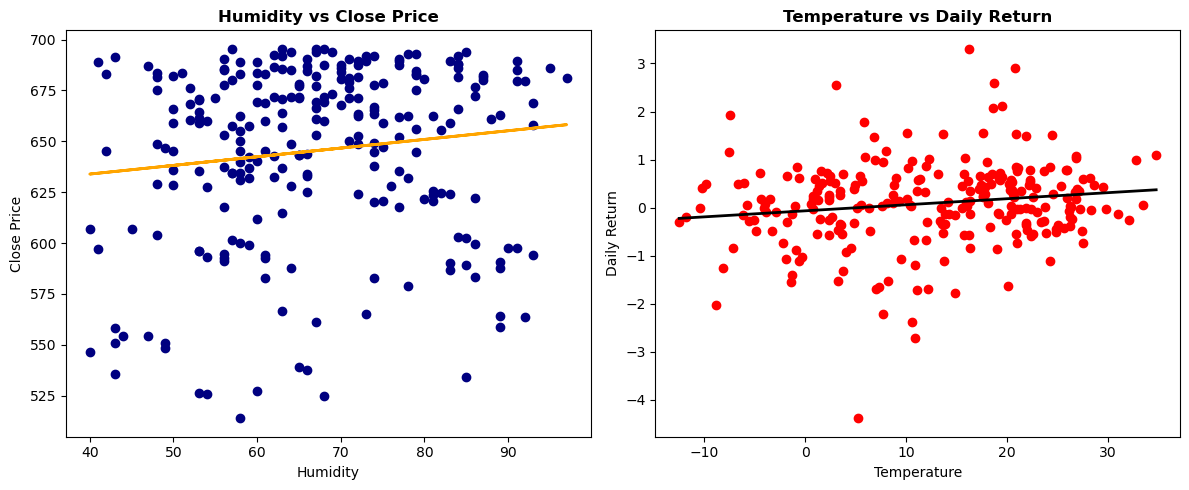

In [63]:
plt.figure(figsize=(12,5))# Creates figure

plt.subplot(1,2,1)# Creates first subplot
plt.scatter(df['humidity'], df['close'], color="navy") # Creates scatterplot for humidity and close price
plt.title('Humidity vs Close Price', fontweight='bold') # Adds title to the graph
plt.ylabel('Close Price') # Labels y-axis
plt.xlabel('Humidity') # Labels x-axis

# trend line
z1 = np.polyfit(df['humidity'], df['close'], 1) # Calculates linear trend line
p1 = np.poly1d(z1)
plt.plot(df['humidity'], p1(df['humidity']), color="orange", linewidth=2) # Draws trend line on the graph


plt.subplot(1,2,2) # Creates second subplot
plt.scatter(df['temperature'], df['daily_return'], color="red") # Creates scatterplot for temperature and daily return
temp_df = df[['temperature','daily_return']].dropna() # Removes missing values from selected columns
plt.title('Temperature vs Daily Return', fontweight='bold') # Adds title to the graph
plt.ylabel('Daily Return') # Labels y-axis
plt.xlabel('Temperature') # Labels x-axis
#trend line
z2 = np.polyfit(temp_df['temperature'], temp_df['daily_return'], 1) # Calculates linear trend line
p2 = np.poly1d(z2)
x_sorted = np.sort(temp_df['temperature']) # Sorts x values for smooth trend line
plt.plot(x_sorted, p2(x_sorted), color="black", linewidth=2) # Draws trend line on the graph

plt.tight_layout() # Adjusts spacing between graphs
plt.savefig("weather_graphs.png", dpi=300) # Saves the graph as png format
plt.show() # Displays the graphs

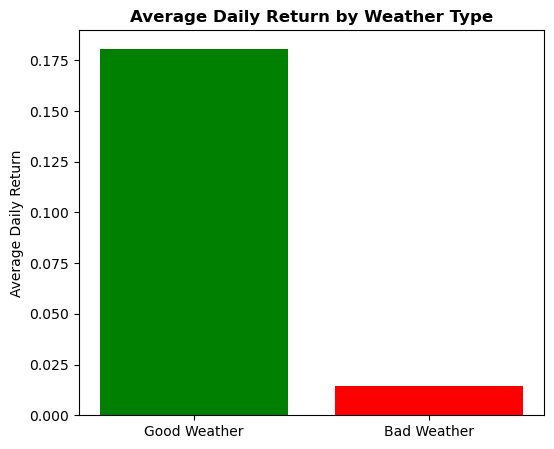

In [65]:
weather_return = [df[df['good_weather'] == 1]['daily_return'].mean(), df[df['bad_weather'] == 1]['daily_return'].mean()] # Calculates average daily return for good and bad weather days
labels = ['Good Weather', 'Bad Weather'] # Creates labels for bar chart categories
plt.figure(figsize=(6,5)) # Creates figure 
plt.bar(labels, weather_return, color=['green', 'red']) # Creates bar chart with green and red colors
plt.title('Average Daily Return by Weather Type', fontweight='bold') # Adds title to the graph
plt.ylabel('Average Daily Return') # Labels y-axis
plt.savefig("Average_Daily_Return_by_Weather_Type.png", dpi=300) # Saves the graph as png format
plt.show()# Displays the graph

### Reference
- https://data36.com/linear-regression-in-python-numpy-polyfit/
- https://www.statology.org/matplotlib-trendline/

## Interpretation of the Graphs
### Humidity vs Close Price
The scatterplot shows the relationship between humidity and S&P 500 closing prices. The trend line has a slight positive slope, that means that higher humidity levels may be associated with slightly higher closing prices. 
### Temperature vs Daily Return
The scatterplot shows the relationship between temperature and daily market returns. The trend line is also slightly positive, that means that warmer temperatures are associated with marginally higher daily returns. 
### Average Daily Return by Weather Type
The bar chart compares the average daily returns during good and bad weather conditions. The graph shows that average returns are higher during good weather days than during bad weather days. This may indicate that favorable weather conditions are associated with more positive market performance.